In [1]:
import torch
import torch.nn as nn
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt


In [2]:
# 1. Define FaceAnalysisModel 
from model import FaceAnalysisModel

# 2. Setup the device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# 3. Instantiate and load
model = FaceAnalysisModel(backbone_requires_grad=False).to(device)
model.load_state_dict(torch.load("face_cnn.pth", map_location=device))

# 4. Set to evaluation mode
model.eval()

FaceAnalysisModel(
  (backbone): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 

In [3]:
# 5. Define Labels
genders = ["Male", "Female"]
ethnicities = ["White", "Black", "Asian", "Indian", "Others"]

# 6. Pre-processing Function
def predict_face(img_path):
    transform = T.Compose([
        T.Grayscale(),
        T.Resize((48, 48)),
        T.ToTensor(),
    ])
    
    img = Image.open(img_path)
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        out_age, out_gender, out_ethnicity = model(img_tensor)
        
    # Extract results
    age = out_age.item()
    gender = genders[out_gender.argmax(1).item()]
    eth = ethnicities[out_ethnicity.argmax(1).item()]
    
    # Display
    plt.imshow(img)
    plt.title(f"Age: {age:.1f} | {gender} | {eth}")
    plt.axis('off')
    plt.show()

In [7]:
from PIL import Image
import torchvision.transforms as T
import torch
import matplotlib.pyplot as plt

def predict_and_show(image_path, model, device, genders, ethnicities):
    # 1. Setup the same pipeline used in training
    transform = T.Compose([
        T.Grayscale(),
        T.Resize((48, 48)),
        T.ToTensor(),
    ])
    
    # 2. Load and prepare the image tensor
    img = Image.open(image_path)
    # .unsqueeze(0) adds the 'batch' dimension the model expects
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    # 3. Run Inference
    model.eval()
    with torch.no_grad():
        out_age, out_gender, out_ethnicity = model(img_tensor)
        
    # 4. Extract and map the results
    age_val = out_age.item()
    gender_idx = out_gender.argmax(1).item()
    eth_idx = out_ethnicity.argmax(1).item()
    
    # 5. Visualize
    plt.imshow(img) 
    plt.title(f"Age: {age_val:.1f} | {genders[gender_idx]} | {ethnicities[eth_idx]}")
    plt.axis('off')
    plt.show()


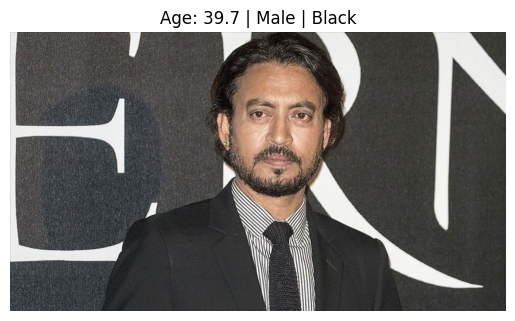

In [ ]:
predict_and_show("./testing_data/Irrfan_khan.jpg", model, device, genders, ethnicities)
